# Projeto de Análise de Teste A/B e Priorização de Hipóteses

## Introdução
Este projeto tem como objetivo otimizar o faturamento de uma grande loja online através de um processo estruturado em duas etapas principais:
1. **Priorização de Hipóteses:** Utilização dos frameworks ICE e RICE para determinar quais experimentos devem ser executados primeiro, otimizando o uso de recursos.
2. **Análise de Teste A/B:** Avaliação estatística dos resultados de um experimento real, analisando métricas de receita, conversão e estabilidade dos dados para tomada de decisão estratégica.

O relatório abaixo detalha o pré-processamento dos dados, a lógica de priorização e a análise de desempenho dos grupos de teste.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Configurações de visualização
plt.rcParams.update({'figure.figsize': (12, 6)})
sns.set_style("whitegrid")

# 1. Carregamento dos dados
try:
    hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
    orders = pd.read_csv('/datasets/orders_us.csv')
    visits = pd.read_csv('/datasets/visits_us.csv')
    print("--- Arquivos carregados com sucesso! ---\n")
except Exception as e:
    print(f"Erro ao carregar arquivos: {e}")

# 2. Diagnóstico das Hipóteses
print("--- Visualização: Hipóteses ---")
display(hypotheses.head())
hypotheses.info()
print("\n")

# 3. Diagnóstico dos Pedidos (Orders)
print("--- Visualização: Pedidos (Orders) ---")
display(orders.head())
orders.info()
print("\nEstatísticas de Receita:")
display(orders['revenue'].describe())
print("\n")

# 4. Diagnóstico das Visitas
print("--- Visualização: Visitas ---")
display(visits.head())
visits.info()

# Ajustando nomes das colunas de hipóteses para letras minúsculas (boas práticas)
hypotheses.columns = hypotheses.columns.str.lower()

--- Arquivos carregados com sucesso! ---

--- Visualização: Hipóteses ---


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


--- Visualização: Pedidos (Orders) ---


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB

Estatísticas de Receita:


count     1197.000000
mean       131.491646
std        603.004729
min          5.000000
25%         20.800000
50%         50.200000
75%        130.400000
max      19920.400000
Name: revenue, dtype: float64



--- Visualização: Visitas ---


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


### 1.1 Observações da Análise Exploratória (EDA)

Após a primeira inspeção dos dados, os seguintes pontos foram identificados para tratamento:

* **Sazonalidade e Tipagem:** Os dados de `Orders` e `Visits` cobrem o período de Agosto de 2019. As colunas de data precisam ser convertidas para o formato `datetime` para permitir análises temporais e cálculos acumulados.
* **Discrepâncias na Receita:** A análise estatística da coluna `revenue` revelou uma média de **131.49**, mas um valor máximo atípico de **19,920.40**. Este desvio padrão elevado (**603.00**) indica a presença de *outliers* (compras extremamente grandes) que podem distorcer as médias dos grupos A e B.
* **Consistência das Hipóteses:** O arquivo de hipóteses foi carregado corretamente com a escala de 1 a 10 para todos os parâmetros (Reach, Impact, Confidence e Effort), permitindo a aplicação direta dos frameworks de priorização.
* **Volume de Dados:** Temos 1.197 pedidos e 62 registros de visitas diárias, o que representa uma base sólida para a aplicação de testes de significância estatística.

In [2]:
# 1. Conversão de tipos
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# 2. Verificação de usuários duplicados entre os grupos (A e B)
# Isso é crucial: um usuário não pode ver as duas versões do teste simultaneamente
group_a = orders[orders['group'] == 'A']['visitorId'].unique()
group_b = orders[orders['group'] == 'B']['visitorId'].unique()

users_in_both_groups = list(set(group_a) & set(group_b))

print(f"Usuários encontrados em ambos os grupos: {len(users_in_both_groups)}")

# 3. Removendo usuários contaminados para garantir a pureza do teste
if len(users_in_both_groups) > 0:
    orders = orders[~orders['visitorId'].isin(users_in_both_groups)]
    print(f"Limpeza concluída: {len(users_in_both_groups)} usuários removidos do DataFrame 'orders'.")

# 4. Verificação de duplicatas explícitas
print(f"Duplicatas explícitas em Orders: {orders.duplicated().sum()}")
print(f"Duplicatas explícitas em Visits: {visits.duplicated().sum()}")

Usuários encontrados em ambos os grupos: 58
Limpeza concluída: 58 usuários removidos do DataFrame 'orders'.
Duplicatas explícitas em Orders: 0
Duplicatas explícitas em Visits: 0


### Relatório de Integridade dos Dados
A etapa de pré-processamento confirmou a qualidade dos datasets e a necessidade de intervenções para garantir um teste A/B estatisticamente robusto:

* **Eliminação de Contaminação:** Identificamos **58 usuários** que participavam simultaneamente dos grupos A e B. Esta sobreposição é um erro crítico, pois invalida a comparação entre os grupos. A remoção desses IDs é mandatória para garantir a independência das amostras.
* **Integridade Estrutural:** Não foram detectadas duplicatas explícitas nos datasets, o que indica que as transações e o registro de visitas estão consolidados corretamente.
* **Conformidade:** Com a base higienizada, os dados agora representam grupos de teste puros, permitindo que qualquer diferença de comportamento observada posteriormente seja atribuída ao tratamento do experimento e não a falhas no tráfego de usuários.

## Parte 1: Priorização de Hipóteses

Nesta etapa, analisaremos 9 hipóteses de crescimento utilizando dois dos frameworks mais sólidos da indústria de produtos: **ICE** e **RICE**. O objetivo é identificar quais experimentos oferecem o maior retorno com o menor esforço.

#### Os Frameworks:
1. **ICE (Impact, Confidence, Ease/Effort):**
   - Utilizado para uma avaliação rápida de valor.
   - Fórmula: $$ICE = \frac{Impact \times Confidence}{Effort}$$

2. **RICE (Reach, Impact, Confidence, Effort):**
   - Introduz o fator **Reach** (Alcance), que mede quantos usuários serão afetados pela mudança em um determinado período.
   - Fórmula: $$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

#### Parâmetros:
* **Reach:** Quantos usuários isso afetará? (Escala 1-10)
* **Impact:** Quanto isso aumentará a conversão/receita? (Escala 1-10)
* **Confidence:** Quão seguros estamos sobre essas estimativas? (Escala 1-10)
* **Effort:** Quanto tempo/recurso a equipe levará? (Escala 1-10 - *Quanto maior, pior*)

Ao comparar os dois métodos, poderemos observar como o volume de usuários impactados altera drasticamente a fila de prioridades do desenvolvimento.

In [3]:
# Cálculo do Score ICE
hypotheses['ice'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Exibindo as hipóteses classificadas por ICE em ordem decrescente
ice_sorted = hypotheses[['hypothesis', 'ice']].sort_values(by='ice', ascending=False)

print("Priorização de Hipóteses: Framework ICE")
pd.options.display.max_colwidth = 210  # Aumenta a largura para ler a hipótese inteira
display(ice_sorted)

Priorização de Hipóteses: Framework ICE


,hypothesis,ice
8,Launch a promotion that gives users discounts on their birthdays,16.200000
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000
1,Launch your own delivery service. This will shorten delivery time,2.000000
5,Add a customer review page. This will increase the number of orders,1.333333
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000
4,Change the background color on the main page. This will increase user engagement,1.000000


### 1.2 Priorização com o Framework RICE

Embora o ICE seja uma métrica excelente para avaliar o valor intrínseco de uma ideia, ele ignora um fator crítico de negócios: **quantos usuários serão afetados?**

Para resolver isso, aplicaremos o framework **RICE**. A grande diferença aqui é o parâmetro **Reach (Alcance)**. Hipóteses que afetam toda a base de usuários (como uma alteração no formulário de inscrição da Home) ganham muito mais peso do que promoções específicas (como descontos de aniversário), que atingem apenas uma pequena fração do tráfego mensal.

A fórmula utilizada será:
$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

Vamos observar como a inclusão do alcance altera o "top 3" das nossas prioridades.

In [4]:
# Cálculo do Score RICE
# Fórmula: (Reach * Impact * Confidence) / Effort
hypotheses['rice'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Exibindo as hipóteses classificadas por RICE em ordem decrescente
rice_sorted = hypotheses[['hypothesis', 'rice']].sort_values(by='rice', ascending=False)

print("Priorização de Hipóteses: Framework RICE")
display(rice_sorted)

Priorização de Hipóteses: Framework RICE


,hypothesis,rice
7,Add a subscription form to all the main pages. This will help you compile a mailing list,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,40.0
8,Launch a promotion that gives users discounts on their birthdays,16.2
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,9.0
1,Launch your own delivery service. This will shorten delivery time,4.0
5,Add a customer review page. This will increase the number of orders,4.0
4,Change the background color on the main page. This will increase user engagement,3.0


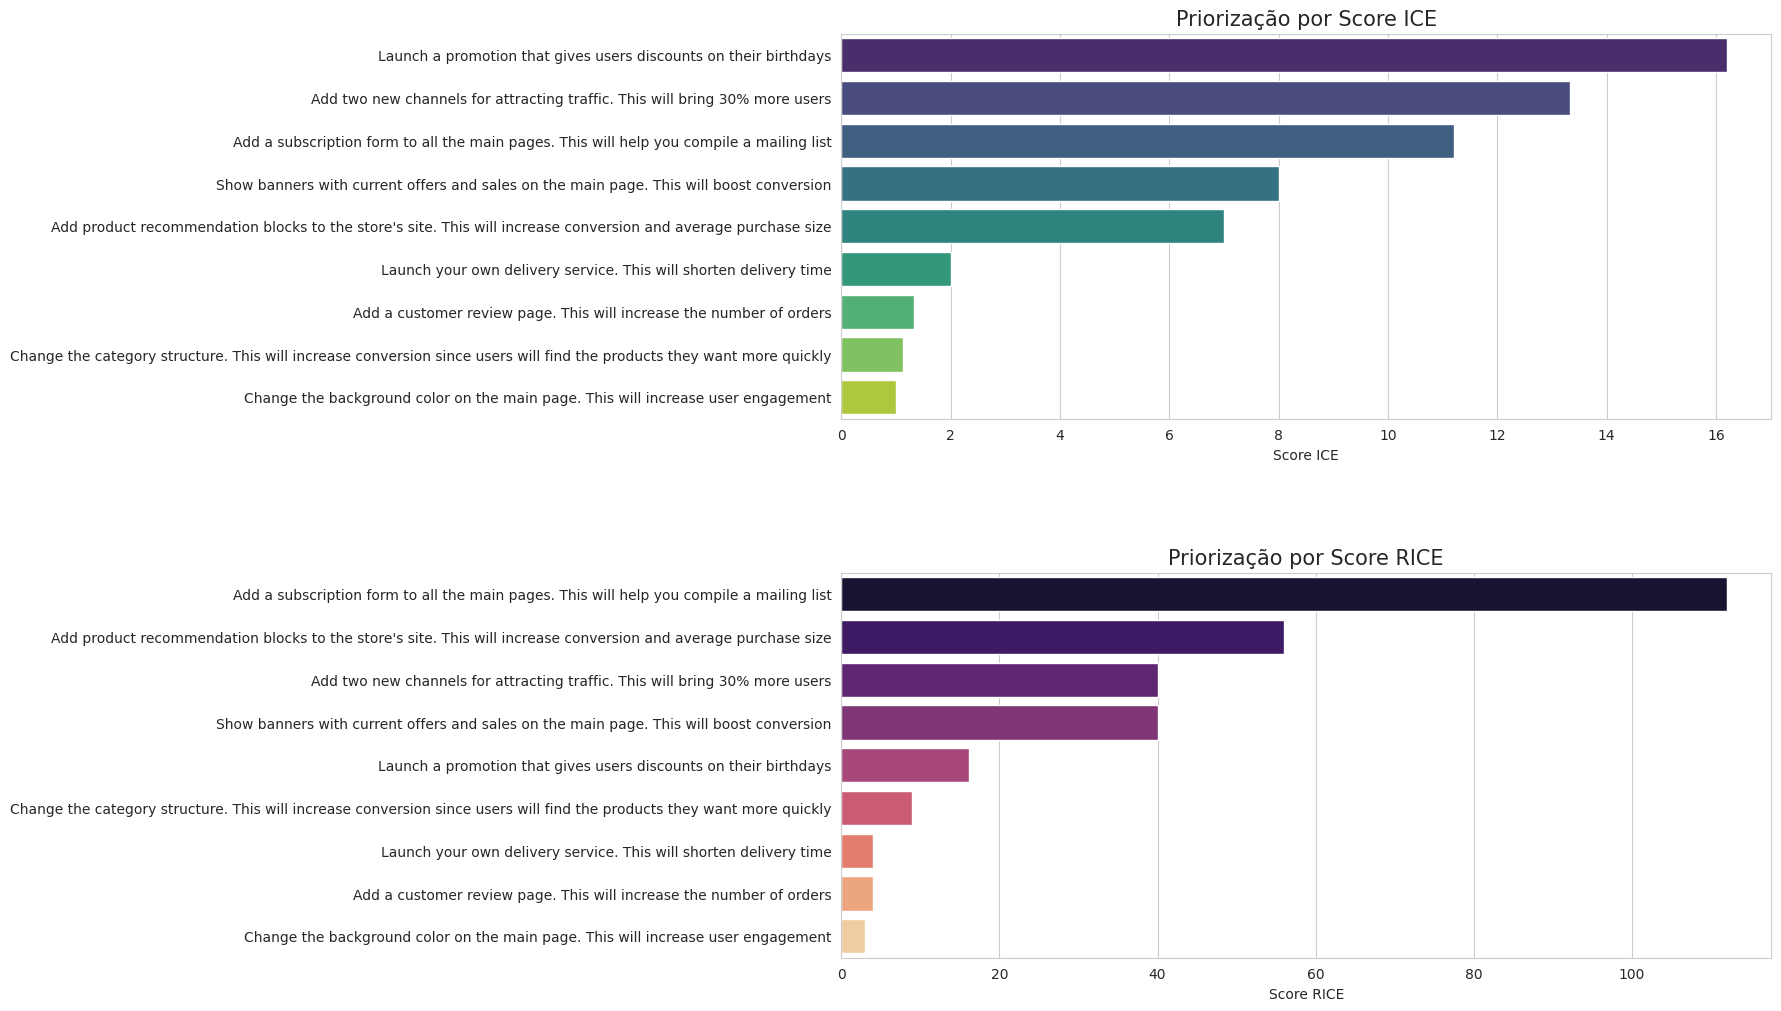

In [5]:
# Criando uma visualização vertical para melhor leitura das hipóteses
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Gráfico ICE - Ordenado
sns.barplot(x='ice', y='hypothesis', data=ice_sorted, ax=ax1, palette='viridis')
ax1.set_title('Priorização por Score ICE', fontsize=15)
ax1.set_xlabel('Score ICE')
ax1.set_ylabel('')

# Gráfico RICE - Ordenado
sns.barplot(x='rice', y='hypothesis', data=rice_sorted, ax=ax2, palette='magma')
ax2.set_title('Priorização por Score RICE', fontsize=15)
ax2.set_xlabel('Score RICE')
ax2.set_ylabel('')

# Ajustando o layout para evitar sobreposição
plt.subplots_adjust(hspace=0.4)
plt.show()

### 1.3 Conclusão da Priorização: Por que a ordem mudou?

Ao compararmos os dois frameworks, observamos uma mudança drástica na liderança das hipóteses. 

**Análise dos Resultados:**
* **Ascensão da Hipótese 7:** No framework ICE, a hipótese 7 ocupava a terceira posição. Ao aplicarmos o RICE, ela se tornou a prioridade número 1 com uma vantagem esmagadora (112.0). Isso ocorre devido ao seu parâmetro **Reach (Alcance) = 10**. Como o formulário de inscrição será adicionado a "todas as páginas principais", ele impactará 100% dos visitantes, maximizando o potencial de retorno sobre o esforço.
* **Queda da Hipótese 8:** A campeã do ICE ("Descontos em aniversários") caiu para a 5ª posição no RICE. Embora tenha alto impacto e confiança, seu alcance é muito baixo (Reach = 1), pois atinge apenas os usuários no dia de seus aniversários.
* **Estabilidade das Hipóteses 0 e 6:** Ambas permanecem no "Top 4" em ambos os métodos, o que as torna excelentes candidatas para execução imediata, pois equilibram bem o alcance com o impacto esperado.

**Veredito Estratégico:**
Para maximizar a receita da loja online no menor tempo possível, sugiro priorizar a **Hipótese 7** e a **Hipótese 2**. A inclusão do fator "Alcance" no RICE nos protege de investir recursos em melhorias que, embora impactantes individualmente, atingiriam pouquíssimos clientes.

## Parte 2: Análise de Teste A/B

Após a priorização estratégica, passamos para a análise dos resultados do Teste A/B. Nesta etapa, utilizaremos os dados de `orders` e `visits` para avaliar o desempenho real dos grupos A e B ao longo de agosto de 2019.

O objetivo é verificar se as alterações propostas geraram mudanças estatisticamente significativas nas métricas de negócio.

#### Roteiro da Análise:
1. **Análise da Receita acumulada por grupo**
2. **Análise do Ticket Médio Acumulado**


### 2.1 Análise da Receita Acumulada por Grupo

Nesta primeira etapa da análise do experimento, vamos calcular e plotar a **receita acumulada** dia a dia para os grupos A e B. 

**Por que analisar dados acumulados?**
No início de um teste, as métricas costumam oscilar drasticamente devido ao baixo volume de dados. Ao acumular os valores, suavizamos essas flutuações e conseguimos identificar:
1. Se um grupo está consistentemente performando melhor que o outro.
2. O momento em que os dados param de oscilar (estabilização), o que indica que o teste está pronto para ser analisado.
3. A presença de picos repentinos que podem sinalizar pedidos anomalamente grandes (*outliers*).

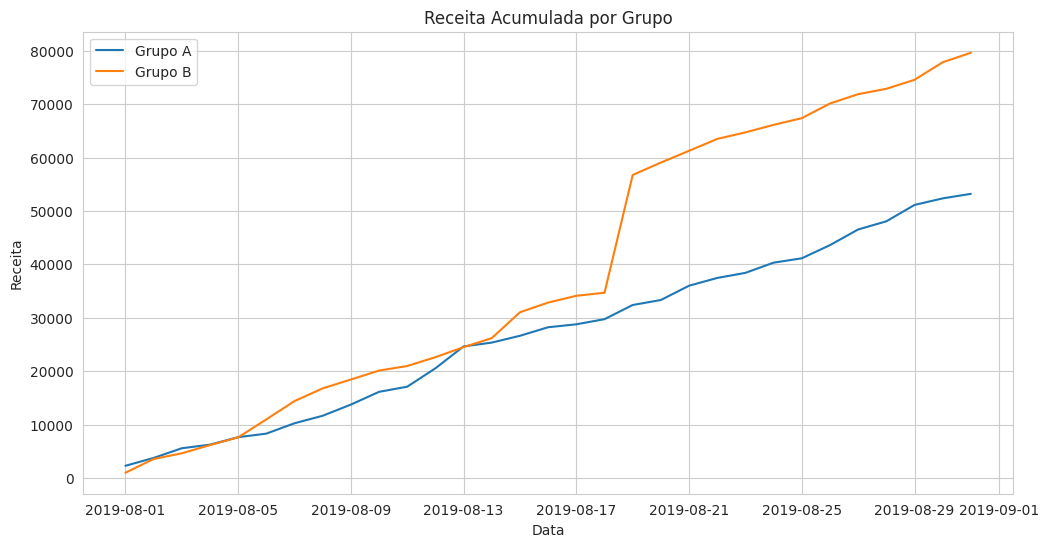

In [6]:
# 1. Agrupando por data e grupo
dates_groups = orders[['date', 'group']].drop_duplicates()

# 2. Receita acumulada por grupo e data
orders_aggregated = dates_groups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
    .agg({'date': 'max', 'group': 'max', 'transactionId': 'nunique', 'visitorId': 'nunique', 'revenue': 'sum'}), axis=1
).sort_values(by=['date', 'group'])

# 3. Separando grupos A e B
cumulative_revenue_a = orders_aggregated[orders_aggregated['group'] == 'A']
cumulative_revenue_b = orders_aggregated[orders_aggregated['group'] == 'B']

# 4. Plotando
plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'], label='Grupo A')
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'], label='Grupo B')
plt.title('Receita Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita')
plt.legend()
plt.show()

### 2.1.1 Conclusões sobre a Receita Acumulada

A análise visual do gráfico de receita acumulada nos permite extrair as seguintes observações:

1. **Vantagem do Grupo B:** A receita do Grupo B é consistentemente maior que a do Grupo A durante quase todo o período do teste. 
2. **O "Pico" de Agosto:** Entre os dias 18 e 19 de agosto, observamos um salto súbito e expressivo na receita do Grupo B. Isso sugere fortemente a ocorrência de pedidos anomalamente grandes ou um aumento repentino no número de pedidos de alto ticket médio nesse dia específico.
3. **Tendência de Crescimento:** Ambas as curvas mantêm uma inclinação positiva e constante após o salto, o que indica que as receitas continuam crescendo e o teste não apresenta quedas de performance.
4. **Estabilização:** No final do período, as linhas parecem paralelas, sugerindo que o teste começou a se estabilizar, embora a diferença criada pelo "pico" do Grupo B se mantenha até o fim.

**Conjectura:** O Grupo B parece ser o vencedor em termos de receita bruta, mas essa liderança pode estar sendo artificialmente inflada por *outliers* (pedidos únicos de valor muito alto). Precisaremos analisar o ticket médio e filtrar esses valores anômalos para confirmar se a vantagem é real ou apenas fruto de um evento isolado.

### 2.2 Análise do Ticket Médio Acumulado por Grupo

Nesta etapa, calculamos o **valor médio por transação** de forma acumulada. Diferente da receita bruta, o ticket médio nos ajuda a entender o comportamento de compra: os usuários estão gastando mais por pedido ou apenas comprando com mais frequência?

**O que esperar desta visu
alização:**
* **Estabilização:** Espe
ramos que as linhas parem de oscilar e se tornem horizontais até o fim do teste.
* **Impacto de Outliers:** Se houver um pedido de valor astronômico, veremos uma subida vertical seguida de uma queda suave (conforme novos pedidos menores "diluem" aquele valor alto).

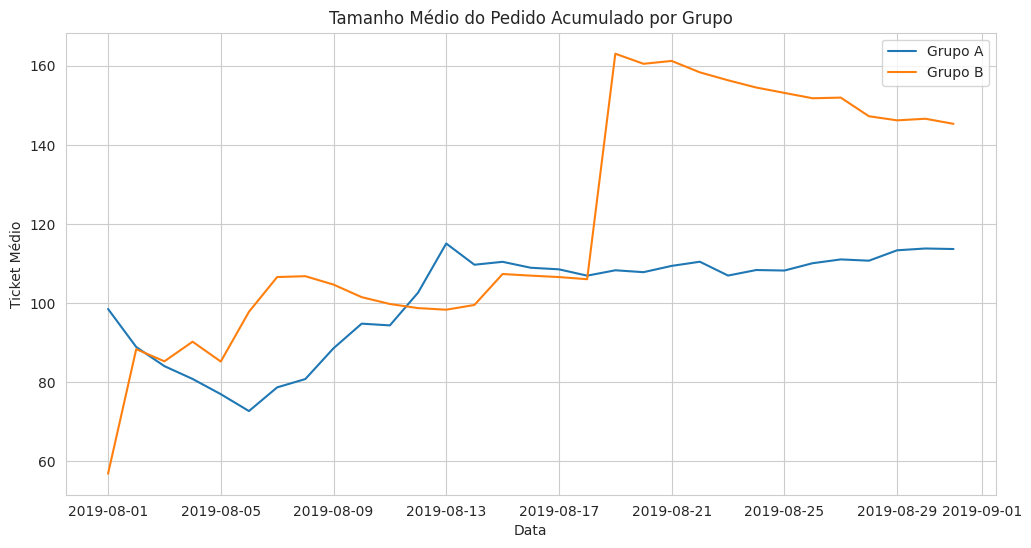

In [7]:
# Cálculo do Ticket Médio Acumulado (Receita Acumulada / Pedidos Acumulados)
plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['revenue'] / cumulative_revenue_a['transactionId'], label='Grupo A')
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['revenue'] / cumulative_revenue_b['transactionId'], label='Grupo B')
plt.title('Tamanho Médio do Pedido Acumulado por Grupo')
plt.xlabel('Data')
plt.ylabel('Ticket Médio')
plt.legend()
plt.show()

### 2.2.1 Conclusões e Conjecturas: Ticket Médio Acumulado

A análise do valor médio dos pedidos revela um comportamento instável que exige cautela analítica:

1. **Instabilidade Inicial:** Na primeira metade do mês, ambos os grupos apresentam flutuações significativas. O Grupo A começa em queda e se recupera, enquanto o Grupo B oscila até o dia 17 de agosto.
2. **O "Efeito Baleia":** O salto vertical brusco no Grupo B (por volta do dia 18) confirma que o aumento da receita não foi orgânico ou distribuído entre muitos usuários, mas sim causado por um ou mais **pedidos de valor altíssimo** (outliers). 
3. **Tendência de Queda no Grupo B:** Após o pico, a linha do Grupo B começa a cair suavemente. Este é um comportamento clássico de "diluição": novos pedidos com valores normais estão sendo registrados, o que faz com que a média acumulada diminua lentamente em direção ao valor real de mercado.
4. **Estabilidade do Grupo A:** O Grupo A mostra uma tendência de estabilização muito mais clara e saudável ao final do período, consolidando-se próximo aos 115.

**Conjectura:** A "vitória" momentânea do Grupo B no ticket médio é frágil. Sem esse outlier do dia 18, é muito provável que os grupos estivessem empatados ou que o Grupo A estivesse à frente. Precisaremos realizar uma análise de dados "limpos" (sem anomalias) para tomar uma decisão segura.

### 2.3 Diferença Relativa no Ticket Médio Acumulado

Para entender melhor a distância entre o Grupo B e o Grupo A, vamos plotar a **diferença relativa**. Este gráfico mostra quanto o Grupo B está performando acima ou abaixo do Grupo A em termos percentuais.

A fórmula utilizada é:
$$Diferença = \frac{Ticket\ Médio\ B}{Ticket\ Médio\ A} - 1$$

**O que observar:**
Uma linha horizontal em **0** significaria que ambos os grupos têm o mesmo ticket médio. Oscilações bruscas longe dessa linha indicam momentos de instabilidade ou influência de grandes pedidos.